In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/competitions/signate_mufgcup2024/notebooks

Mounted at /content/drive
/content/drive/MyDrive/competitions/signate_mufgcup2024/notebooks


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from datetime import datetime
from sklearn.preprocessing import LabelEncoder
from scipy.stats import linregress

In [3]:
# configの読み込み
CONFIG_FILE = '../configs/config.yaml'
with open(CONFIG_FILE, encoding="utf-8") as file:
    yml = yaml.safe_load(file)

In [4]:
DIR_INPUT = yml["SETTING"]["DIR_INPUT"]
DIR_INTERIM = yml["SETTING"]["DIR_INTERIM"]
DIR_FEATURE = yml["SETTING"]["DIR_FEATURE"]
DIR_FIGURE = yml["SETTING"]["DIR_FIGURE"]
DIR_HOME = yml["SETTING"]["DIR_HOME"]
DIR_LOG = yml["SETTING"]["DIR_LOG"]
DIR_SUBMISSION = yml["SETTING"]["DIR_SUBMISSION"]
DIR_MODEL = yml["SETTING"]["DIR_MODEL"]
FILE_NAME_STATION = yml["SETTING"]["FILE_NAME_STATION"]
FILE_NAME_STATUS = yml["SETTING"]["FILE_NAME_STATUS"]
FILE_NAME_TRIP = yml["SETTING"]["FILE_NAME_TRIP"]
FILE_NAME_WEATHER = yml["SETTING"]["FILE_NAME_WEATHER"]

In [5]:
# 自作モジュールの読み込み
import sys
sys.path.append(DIR_HOME)
from src.util import Logger, Util

In [6]:
pd.set_option("display.max_columns",200)
pd.set_option("display.max_rows", 500)

# データ読み込み

In [7]:
dict_dtype_station = {
    "station_id": "int64",
    "lat": "float64",
    "long": "float64",
    "dock_count": "int64",
    "city": "object",
    "installation_date": "object",
}
dict_dtype_status = {
    "id": "int64",
    "year": "int64",
    "month": "int64",
    "day": "int64",
    "hour": "int64",
    "station_id": "int64",
    "bikes_available": "float64",
    "predict": "int64",
}
dict_dtype_trip = {
    "trip_id": "int64",
    "duration": "int64",
    "start_date": "object",
    "start_station_id": "int64",
    "end_date": "object",
    "end_station_id": "int64",
    "bike_id": "int64",
    "subscription_type": "object",
}
dict_dtype_weather = {
    "date": "object",
    "max_temperature": "int64",
    "mean_temperature": "int64",
    "min_temperature": "int64",
    "max_dew_point": "int64",
    "mean_dew_point": "int64",
    "min_dew_point": "int64",
    "max_humidity": "int64",
    "mean_humidity": "int64",
    "min_humidity": "int64",
    "max_sea_level_pressure": "float64",
    "mean_sea_level_pressure": "float64",
    "min_sea_level_pressure": "float64",
    "max_visibility": "int64",
    "mean_visibility": "int64",
    "min_visibility": "int64",
    "max_wind_Speed": "int64",
    "mean_wind_speed": "int64",
    "precipitation": "float64",
    "cloud_cover": "int64",
    "events": "object",
    "wind_dir_degrees": "int64",
}

In [8]:
df_station = pd.read_csv(os.path.join(DIR_INPUT, FILE_NAME_STATION), dtype=dict_dtype_station)
df_status = pd.read_csv(os.path.join(DIR_INPUT, FILE_NAME_STATUS), dtype=dict_dtype_status)
df_trip = pd.read_csv(os.path.join(DIR_INPUT, FILE_NAME_TRIP), dtype=dict_dtype_trip)
df_weather = pd.read_csv(os.path.join(DIR_INPUT, FILE_NAME_WEATHER), dtype=dict_dtype_weather)

# 前処理

In [9]:
def convert_datetime(df_station, df_status, df_trip, df_weather):
    df_station["installation_date"] = pd.to_datetime(df_station["installation_date"], format='%m/%d/%Y').dt.date
    df_status["datetime"] = pd.to_datetime(df_status[["year", "month", "day", "hour"]])
    df_trip["start_date"] = pd.to_datetime(df_trip["start_date"], format='%m/%d/%Y %H:%M')
    df_trip["end_date"] = pd.to_datetime(df_trip["end_date"], format='%m/%d/%Y %H:%M')
    df_weather["date"] = pd.to_datetime(df_weather["date"], format='%Y-%m-%d').dt.date

    return df_station, df_status, df_trip, df_weather

In [10]:
df_station, df_status, df_trip, df_weather = convert_datetime(df_station, df_status, df_trip, df_weather)

In [11]:
# データ出力
df_station.to_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
df_status.to_pickle(os.path.join(DIR_INTERIM, "df_prep_status.pkl"))
df_trip.to_pickle(os.path.join(DIR_INTERIM, "df_prep_trip.pkl"))
df_weather.to_pickle(os.path.join(DIR_INTERIM, "df_prep_weather.pkl"))

# 特徴量作成

In [12]:
from pathlib import Path
from abc import ABCMeta, abstractmethod

In [13]:
from time import time

def decorate(s: str, decoration=None):
    if decoration is None:
        decoration = '★' * 20

    return ' '.join([decoration, str(s), decoration])

class Timer:
    def __init__(self, logger=None, format_str='{:.3f}[s]', prefix=None, suffix=None, sep=' ', verbose=0):

        if prefix: format_str = str(prefix) + sep + format_str
        if suffix: format_str = format_str + sep + str(suffix)
        self.format_str = format_str
        self.logger = logger
        self.start = None
        self.end = None
        self.verbose = verbose

    @property
    def duration(self):
        if self.end is None:
            return 0
        return self.end - self.start

    def __enter__(self):
        self.start = time()

    def __exit__(self, exc_type, exc_val, exc_tb):
        self.end = time()
        if self.verbose is None:
            return
        out_str = self.format_str.format(self.duration)
        if self.logger:
            self.logger.info(out_str)
        else:
            print(out_str)

In [14]:
class AbstractBaseBlock(metaclass=ABCMeta):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        self.use_cache = use_cache
        self.name = self.__class__.__name__
        self.cache_dir = Path(DIR_FEATURE)
        self.logger = logger
        self.seve_cache = save_cache
        self.use_cols = None

    # 内部状態の更新
    def fit(self, df_input: pd.DataFrame, y=None):
        pass

    # 変換処理
    @abstractmethod
    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        raise NotImplementedError()

    # 内部状態の更新と変換処理をまとめて行う
    def fit_transform(self, X: pd.DataFrame, y=None):
        self.fit(X, y)
        return self.transform(X)

    # 特徴量生成処理
    def create_feature(self, X, y=None, test=False, limit_date="yyyy-mm-dd") -> pd.DataFrame:

        # クラス名.pkl
        file_name = os.path.join(self.cache_dir, limit_date, f"{self.name}.pkl")

        # キャッシュを使う & ファイルがあるなら読み出し
        if os.path.isfile(str(file_name)) and self.use_cache:
            return pd.read_pickle(file_name)

        # 変換処理を実行
        else:
            # trainの場合
            if not test:
                feature = self.fit_transform(X, y)
            # testの場合
            else:
                feature = self.transform(X)
            # 保存する場合
            if self.seve_cache:
                feature.to_pickle(file_name)

            return feature

In [15]:
# そのままの特徴量を返すBlock

In [16]:
# 静的特徴量
# 動的特徴量

In [17]:
class AsIsNumetricBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = [
            'CityTier',
            'DurationOfPitch',
            'NumberOfPersonVisiting',
            'NumberOfFollowups',
            'PreferredPropertyStar',
            'NumberOfTrips',
            'Passport',
            'PitchSatisfactionScore',
            'MonthlyIncome',
            'ProdTaken' # 目的関数
        ]
        self.key_col = ["id"]
        self.map_count = None

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out = df_input[self.key_col + self.use_cols]
        return df_out

class AsIsCategoryBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = [
            'Age',
            'TypeofContact',
            'Occupation',
            'Gender',
            'ProductPitched',
            'Designation',
            'customer_info',
            'marry',
            'car',
            'child',
        ]
        self.key_col = ["id"]
        self.map_count = None

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out = df_input[self.key_col + self.use_cols]
        return df_out

In [18]:
class CountEncodingBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = [
            "TypeofContact", "CityTier", "Occupation", "ProductPitched",
            "Designation", "marry", "car"
        ]
        self.key_col = ["id"]
        self.map_count = None

    def fit(self, df_input, y=None):
        # カラムごとにマッピング表を作成
        self.map_count = {}
        for col in self.use_cols:
            self.map_count[col] = df_input[col].fillna("NA").value_counts()

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out[self.key_col] = df_input[self.key_col]
        for col in self.use_cols:
            df_out[col] = df_input[col].fillna("NA").map(self.map_count[col]).astype(int)
        # id以外のカラム名に接頭辞を付ける
        df_result = pd.concat([df_out[self.key_col], df_out.drop(columns=self.key_col).add_prefix('CE_')], axis=1)
        return df_result

class TargetEncodingBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = [
            "TypeofContact", "CityTier", "Occupation", "ProductPitched",
            "Designation", "marry", "car"
        ]
        self.key_col = ["id"]
        self.map_target = None

    def fit(self, df_input, y):
        # カラムごとにマッピング表を作成
        self.map_target = {}
        for col in self.use_cols:
            self.map_target[col] = df_input.groupby(col)[TARGET_COL].mean()

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out[self.key_col] = df_input[self.key_col]
        for col in self.use_cols:
            df_out[col] = df_input[col].map(self.map_target[col]).astype(float)
        # id以外のカラム名に接頭辞を付ける
        df_result = pd.concat([df_out[self.key_col], df_out.drop(columns=self.key_col).add_prefix('TE_')], axis=1)
        return df_result

# 大分類を作成するクラス
class BigCategoryBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = []
        self.key_col = ["id"]
        self.map_target = None

    def fit(self, df_input, y=None):
        pass

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out[self.key_col] = df_input[self.key_col]
        df_out["Age"] = df_input["Age"].apply(lambda x: self.replace_sai_to_dai(x) if not pd.isna(x) else x)
        # id以外のカラム名に接頭辞を付ける
        df_result = pd.concat([df_out[self.key_col], df_out.drop(columns=self.key_col).add_prefix('BC_')], axis=1)
        return df_result

    def replace_sai_to_dai(self, age):
        first_char = age[0]
        if first_char == "1":
            result = "10代"
        elif first_char == "2":
            result = "20代"
        elif first_char == "3":
            result = "30代"
        elif first_char == "4":
            result = "40代"
        elif first_char == "5":
            result = "50代"
        elif first_char == "6":
            result = "60代"
        return result

# 大分類を作成するクラス
class BigCategoryBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = []
        self.key_col = ["id"]
        self.map_target = None

    def fit(self, df_input, y=None):
        pass

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out[self.key_col] = df_input[self.key_col]
        df_out["Age"] = df_input["Age"].apply(lambda x: self.replace_sai_to_dai(x) if not pd.isna(x) else x)
        # id以外のカラム名に接頭辞を付ける
        df_result = pd.concat([df_out[self.key_col], df_out.drop(columns=self.key_col).add_prefix('BC_')], axis=1)
        return df_result

    def replace_sai_to_dai(self, age):
        first_char = age[0]
        if first_char == "1":
            result = "10代"
        elif first_char == "2":
            result = "20代"
        elif first_char == "3":
            result = "30代"
        elif first_char == "4":
            result = "40代"
        elif first_char == "5":
            result = "50代"
        elif first_char == "6":
            result = "60代"
        return result

In [19]:
def run_blocks(df_input, feature_blocks, y=None, test=False):
    df_out = None

    print(decorate('start run blocks...'))

    with Timer(prefix='run test={}'.format(test)):
        for block in feature_blocks:
            with Timer(prefix='\t- {}'.format(str(block))):
                feature = block.create_feature(df_input, y=y, test=test)
            assert len(df_input) == len(feature), block
            if df_out is None:
                df_out = feature
            else:
                df_out = pd.merge(df_out, feature, on=["id"], how="left")

    return df_out

In [20]:
feature_blocks = [
    *[AsIsCategoryBlock(use_cache=False, save_cache=True, logger=None)],
    *[AsIsNumetricBlock(use_cache=True, save_cache=True, logger=None)],
    *[CountEncodingBlock(use_cache=True, save_cache=True, logger=None)],
    *[TargetEncodingBlock(use_cache=True, save_cache=True, logger=None)],
    *[BigCategoryBlock(use_cache=True, save_cache=True, logger=None)],
]

In [21]:
df_preprocessed = pd.read_pickle(os.path.join(DIR_INTERIM, "preprocessed.pkl"))

FileNotFoundError: [Errno 2] No such file or directory: '../data/interim/preprocessed.pkl'

In [ ]:
df_out = run_blocks(df_preprocessed, feature_blocks, y=None, test=False)

# 特徴量生成

In [22]:
df_prep_status = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_status.pkl"))
df_prep_trip = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_trip.pkl"))
df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
df_prep_weather = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_weather.pkl"))

In [23]:
def save_feature(df, file_name):
    file_name = file_name + ".pkl"
    df.to_pickle(os.path.join(DIR_FEATURE, file_name))

def load_feature(file_name):
    file_name = file_name + ".pkl"
    return pd.read_pickle(os.path.join(DIR_FEATURE, file_name))

def assert_data(df, key):
    # キーの重複を確認
    assert df[key].duplicated().sum() == 0, "key duplicate"
    # 欠損値の確認
    print("missing value: ")
    print(df.isnull().sum())

def assert_and_save_feature(df, key, file_name):
    assert_data(df, key)
    save_feature(df, file_name)

In [24]:
# keyデータの作成
df_key = df_prep_status[["station_id", "datetime"]].copy()
assert_and_save_feature(df_key, ["station_id", "datetime"], "df_key")

missing value: 
station_id    0
datetime      0
dtype: int64


In [25]:
# 目的変数
df_target = df_prep_status[["station_id", "datetime", "bikes_available"]].copy()
assert_and_save_feature(df_target, ["station_id", "datetime"], "df_target")

missing value: 
station_id              0
datetime                0
bikes_available    218522
dtype: int64


In [26]:
# predictデータの作成
df_predict = df_prep_status[["station_id", "datetime", "predict"]].copy()
assert_and_save_feature(df_predict, ["station_id", "datetime"], "df_predict")

missing value: 
station_id    0
datetime      0
predict       0
dtype: int64


In [27]:
# 欠損値補完
def create_fillna_feature(df, target_col):
    df_ = pd.merge(df, load_feature("df_predict"), on=["station_id", "datetime"], how="left")
    df_fillna = pd.DataFrame()
    for station_id in df_["station_id"].unique().tolist():
        temp_df = df_[df_["station_id"]==station_id]
        ## 前の値で欠損値補完
        temp_df = temp_df.ffill()
        ## predict==1のデータをnullにする
        temp_df.loc[temp_df["predict"]==1, target_col] = np.nan
        df_fillna = pd.concat([df_fillna,temp_df])[["station_id", "datetime",target_col]]
    return df_fillna

In [28]:
df_bikes_available_fillna = create_fillna_feature(df_target, "bikes_available")
assert_and_save_feature(df_bikes_available_fillna, ["station_id", "datetime"], "df_bikes_available_fillna")

missing value: 
station_id              0
datetime                0
bikes_available    214805
dtype: int64


In [29]:
# ラグ特徴量の作成
def create_lag_feature(df, key_cols, target_cols, lag):
    df_lag = df[key_cols].copy()
    for target_col in target_cols:
        for i in range(0, lag+1):
            df_shift = df[key_cols + [target_col]].copy()
            df_shift["datetime"] = df_shift["datetime"] + pd.Timedelta(hours=i)
            df_shift.columns = key_cols + [f"{target_col}_lag{i}"]
            df_lag = pd.merge(df_lag, df_shift, on=key_cols, how="left")
    return df_lag



In [30]:
lag = 48
df_bikes_available_lag = df_bikes_available_fillna.copy()
df_bikes_available_lag = create_lag_feature(df_bikes_available_lag, ["station_id", "datetime"], ["bikes_available"], lag)
assert_and_save_feature(df_bikes_available_lag, ["station_id", "datetime"], "df_bikes_available_lag")

missing value: 
station_id                    0
datetime                      0
bikes_available_lag0     214805
bikes_available_lag1     214875
bikes_available_lag2     214945
bikes_available_lag3     215015
bikes_available_lag4     215085
bikes_available_lag5     215155
bikes_available_lag6     215225
bikes_available_lag7     215295
bikes_available_lag8     215365
bikes_available_lag9     215435
bikes_available_lag10    215505
bikes_available_lag11    215575
bikes_available_lag12    215645
bikes_available_lag13    215715
bikes_available_lag14    215785
bikes_available_lag15    215855
bikes_available_lag16    215925
bikes_available_lag17    215995
bikes_available_lag18    216065
bikes_available_lag19    216135
bikes_available_lag20    216205
bikes_available_lag21    216275
bikes_available_lag22    216345
bikes_available_lag23    216415
bikes_available_lag24    216485
bikes_available_lag25    216555
bikes_available_lag26    216625
bikes_available_lag27    216695
bikes_available_lag28   

In [31]:
# diff・需要・供給・予測データの作成
trip_data = df_prep_trip.copy()
trip_data['start_hour'] = pd.to_datetime(trip_data['start_date']).dt.floor('h')
trip_data['end_hour'] = pd.to_datetime(trip_data['end_date']).dt.floor('h')

## 出発（需要）を集計
## 過去1時間の需要を集計
departures = trip_data.groupby(['start_station_id', 'start_hour']).size().reset_index(name='demand')
departures["datetime"] = departures["start_hour"] + pd.Timedelta(hours=1)
departures.rename(columns={"start_station_id": "station_id"}, inplace=True)
## 到着（供給）を集計
## 過去1時間の供給を集計
arrivals = trip_data.groupby(['end_station_id', 'end_hour']).size().reset_index(name='supply')
arrivals["datetime"] = arrivals["end_hour"] + pd.Timedelta(hours=1)
arrivals.rename(columns={"end_station_id": "station_id"}, inplace=True)

## bikes_availableを需要・供給・介入に分解
df_status_detail = df_prep_status[["station_id", "datetime", "bikes_available"]].copy()
df_status_detail['datetime'] = pd.to_datetime(df_status_detail['datetime']).dt.floor('h')

## 前の時間との利用可能数の差分を計算
df_status_detail = df_status_detail.sort_values(['station_id', 'datetime'])
df_status_detail['bikes_available_diff'] = df_status_detail.groupby('station_id')['bikes_available'].diff()

## 需要・供給を結合
df_status_detail = df_status_detail.merge(departures, on=['station_id', 'datetime'], how='left')
df_status_detail = df_status_detail.merge(arrivals, on=['station_id', 'datetime'], how='left')
df_status_detail["demand"] = -df_status_detail["demand"]
df_status_detail["demand"] = df_status_detail["demand"].fillna(0)
df_status_detail["supply"] = df_status_detail["supply"].fillna(0)

## 介入を計算
## 過去１時間の介入を計算
df_status_detail['intervention'] = df_status_detail['bikes_available_diff'] - (df_status_detail['demand'] + df_status_detail['supply'])

df_demand = df_status_detail[['station_id', 'datetime', 'demand']].copy()
df_supply = df_status_detail[['station_id', 'datetime', 'supply']].copy()
df_intervention = df_status_detail[['station_id', 'datetime', 'intervention']].copy()
assert_and_save_feature(df_demand, ["station_id", "datetime"], "df_demand")
assert_and_save_feature(df_supply, ["station_id", "datetime"], "df_supply")
assert_and_save_feature(df_intervention, ["station_id", "datetime"], "df_intervention")

missing value: 
station_id    0
datetime      0
demand        0
dtype: int64
missing value: 
station_id    0
datetime      0
supply        0
dtype: int64
missing value: 
station_id           0
datetime             0
intervention    227492
dtype: int64


In [32]:
# 欠損値補完
df_intervention_fillna = create_fillna_feature(df_intervention, "intervention")
assert_and_save_feature(df_intervention_fillna, ["station_id", "datetime"], "df_intervention_fillna")

missing value: 
station_id           0
datetime             0
intervention    214875
dtype: int64


In [33]:
# 需要・供給・介入のラグ特徴量を作成
df_demand_lag = create_lag_feature(df_demand, ["station_id", "datetime"], ["demand"], 24)
df_supply_lag = create_lag_feature(df_supply, ["station_id", "datetime"], ["supply"], 24)
df_intervention_lag = create_lag_feature(df_intervention_fillna, ["station_id", "datetime"], ["intervention"], 24)
assert_and_save_feature(df_demand_lag, ["station_id", "datetime"], "df_demand_lag")
assert_and_save_feature(df_supply_lag, ["station_id", "datetime"], "df_supply_lag")
assert_and_save_feature(df_intervention_lag, ["station_id", "datetime"], "df_intervention_lag")

missing value: 
station_id         0
datetime           0
demand_lag0        0
demand_lag1       70
demand_lag2      140
demand_lag3      210
demand_lag4      280
demand_lag5      350
demand_lag6      420
demand_lag7      490
demand_lag8      560
demand_lag9      630
demand_lag10     700
demand_lag11     770
demand_lag12     840
demand_lag13     910
demand_lag14     980
demand_lag15    1050
demand_lag16    1120
demand_lag17    1190
demand_lag18    1260
demand_lag19    1330
demand_lag20    1400
demand_lag21    1470
demand_lag22    1540
demand_lag23    1610
demand_lag24    1680
dtype: int64
missing value: 
station_id         0
datetime           0
supply_lag0        0
supply_lag1       70
supply_lag2      140
supply_lag3      210
supply_lag4      280
supply_lag5      350
supply_lag6      420
supply_lag7      490
supply_lag8      560
supply_lag9      630
supply_lag10     700
supply_lag11     770
supply_lag12     840
supply_lag13     910
supply_lag14     980
supply_lag15    1050
supply_lag

In [34]:
# 各日の00:00からのcumsumに変換
def calc_cumsum_from_00(df_, col):
    df_["date"] = df_["datetime"].dt.date
    df_[f"{col}_cumsum"] = df_.groupby(["station_id", "date"])[col].cumsum()
    df_ = df_.drop(columns=[col, "date"])
    return df_

df_demand_cumsum = calc_cumsum_from_00(df_demand, "demand")
df_supply_cumsum = calc_cumsum_from_00(df_supply, "supply")
df_intervention_cumsum = calc_cumsum_from_00(df_intervention_fillna, "intervention")
assert_and_save_feature(df_demand_cumsum, ["station_id", "datetime"], "df_demand_cumsum")
assert_and_save_feature(df_supply_cumsum, ["station_id", "datetime"], "df_supply_cumsum")
assert_and_save_feature(df_intervention_cumsum, ["station_id", "datetime"], "df_intervention_cumsum")

missing value: 
station_id       0
datetime         0
demand_cumsum    0
dtype: int64
missing value: 
station_id       0
datetime         0
supply_cumsum    0
dtype: int64
missing value: 
station_id                  0
datetime                    0
intervention_cumsum    214875
dtype: int64


In [35]:
# cumsumのラグ特徴量を作成
df_demand_cumsum_lag = create_lag_feature(df_demand_cumsum, ["station_id", "datetime"], ["demand_cumsum"], 24)
df_supply_cumsum_lag = create_lag_feature(df_supply_cumsum, ["station_id", "datetime"], ["supply_cumsum"], 24)
df_intervention_cumsum_lag = create_lag_feature(df_intervention_cumsum, ["station_id", "datetime"], ["intervention_cumsum"], 24)
assert_and_save_feature(df_demand_cumsum_lag, ["station_id", "datetime"], "df_demand_cumsum_lag")
assert_and_save_feature(df_supply_cumsum_lag, ["station_id", "datetime"], "df_supply_cumsum_lag")
assert_and_save_feature(df_intervention_cumsum_lag, ["station_id", "datetime"], "df_intervention_cumsum_lag")

missing value: 
station_id                0
datetime                  0
demand_cumsum_lag0        0
demand_cumsum_lag1       70
demand_cumsum_lag2      140
demand_cumsum_lag3      210
demand_cumsum_lag4      280
demand_cumsum_lag5      350
demand_cumsum_lag6      420
demand_cumsum_lag7      490
demand_cumsum_lag8      560
demand_cumsum_lag9      630
demand_cumsum_lag10     700
demand_cumsum_lag11     770
demand_cumsum_lag12     840
demand_cumsum_lag13     910
demand_cumsum_lag14     980
demand_cumsum_lag15    1050
demand_cumsum_lag16    1120
demand_cumsum_lag17    1190
demand_cumsum_lag18    1260
demand_cumsum_lag19    1330
demand_cumsum_lag20    1400
demand_cumsum_lag21    1470
demand_cumsum_lag22    1540
demand_cumsum_lag23    1610
demand_cumsum_lag24    1680
dtype: int64
missing value: 
station_id                0
datetime                  0
supply_cumsum_lag0        0
supply_cumsum_lag1       70
supply_cumsum_lag2      140
supply_cumsum_lag3      210
supply_cumsum_lag4      280
sup

In [36]:
# 全ての目的変数を作成
df_target_all = df_target.copy()
df_target_all["demand"] = df_status_detail["demand"]
df_target_all["supply"] = df_status_detail["supply"]
df_target_all["intervention"] = df_status_detail["intervention"]
df_target_all["demand_cumsum"] = df_demand_cumsum["demand_cumsum"]
df_target_all["supply_cumsum"] = df_supply_cumsum["supply_cumsum"]
df_target_all["intervention_cumsum"] = df_intervention_cumsum["intervention_cumsum"]
df_target_all["demand_suplly_cumsum"] = df_target_all["demand_cumsum"] + df_target_all["supply_cumsum"]
assert_and_save_feature(df_target_all, ["station_id", "datetime"], "df_target_all")

missing value: 
station_id                   0
datetime                     0
bikes_available         218522
demand                       0
supply                       0
intervention            227492
demand_cumsum                0
supply_cumsum                0
intervention_cumsum     214875
demand_suplly_cumsum         0
dtype: int64


In [37]:
# predictの検証データ用のフラグを立てる
def create_valid_flag(df_result):
    # テストデータと2日以上離れているデータを検証データとする
    df_ = df_result.copy()
    df_ = df_[df_["predict"] != 0]
    df_["date"] = df_["datetime"].dt.date
    df_ = df_[["date","predict"]].drop_duplicates()
    df_["diff"] = df_["date"].diff().dt.days
    df_["yesterday"] = df_["date"].apply(lambda x: x - pd.Timedelta(days=1))
    list_valid_date = df_[df_["diff"] >= 4.0]["yesterday"].tolist()
    # dateがlist_valid_dateに含まれている場合はpredictを2にする
    df_result_ = df_result.copy()
    df_result_["predict"] = df_result_.apply(lambda x: 2 if (x["datetime"].date() in list_valid_date) & (x["datetime"].hour!=0) else x["predict"], axis=1)
    return df_result_

def create_add_valid_dataset(df_main):
    """検証データのフラグを立てる
    """
    df_main_ = df_main.copy()
    df_main_ = df_main_.sort_values(["datetime","station_id"],ascending=True).reset_index(drop=True)
    past_2_len = 0
    while True:
        df_main_ = create_valid_flag(df_main_)
        current_2_len = len(df_main_[df_main_["predict"] == 2])
        if current_2_len == past_2_len:
            break
        past_2_len = current_2_len

    return df_main_

df_predict_add_valid_flag = create_add_valid_dataset(df_predict)
assert_and_save_feature(df_predict_add_valid_flag, ["station_id", "datetime"], "df_predict_add_valid_flag")
print(df_predict_add_valid_flag.groupby("predict").size())

missing value: 
station_id    0
datetime      0
predict       0
dtype: int64
predict
0    928550
1    193200
2    104650
dtype: int64


In [38]:
from sklearn.cluster import KMeans

In [39]:
# stationに関する特徴量を作成
# keyはstation_id
df_station_atr = df_prep_station.copy()
# staion_idの特徴量を追加
df_station_atr["station_id_feat"] = df_station_atr["station_id"]
# installation_dateに関する特徴量を追加
df_station_atr["installation_year"] = df_station_atr["installation_date"].apply(lambda x: x.year)
df_station_atr["installation_month"] = df_station_atr["installation_date"].apply(lambda x: x.month)
df_station_atr["installation_day"] = df_station_atr["installation_date"].apply(lambda x: x.day)
df_station_atr["installation_date"] = df_station_atr["installation_date"].apply(lambda x: int(x.strftime('%Y%m%d')))
# ダミー変数化
df_station_atr = pd.get_dummies(df_station_atr, columns=['city'], dtype="int64")
# クラスタリング
# 2014-09-01までのデータの時間別変動でstation_idをクラスタリングする
df_status_20140901 = df_prep_status[df_prep_status["datetime"] < "2014-09-01"]
df_status_20140901 = df_status_20140901.groupby(["station_id", "hour"])["bikes_available"].mean().unstack().fillna(0)
# 0時からの変動を計算
df_status_20140901 = df_status_20140901.reset_index()
for i in range(1, 24):
    df_status_20140901[i] = df_status_20140901[i] - df_status_20140901[0]
df_status_20140901 = df_status_20140901.drop(columns=[0, "station_id"])
# クラスタリング
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(df_status_20140901)
df_station_cluster = pd.DataFrame()
df_station_cluster["station_id"] = df_status_20140901.index
df_station_cluster["cluster"] = kmeans.labels_
df_station_atr = pd.merge(df_station_atr, df_station_cluster, on="station_id", how="left")

assert_and_save_feature(df_station_atr, ["station_id"], "df_station_atr")

missing value: 
station_id            0
lat                   0
long                  0
dock_count            0
installation_date     0
station_id_feat       0
installation_year     0
installation_month    0
installation_day      0
city_city1            0
city_city2            0
city_city3            0
city_city4            0
city_city5            0
cluster               0
dtype: int64


In [40]:
# 2014-09-01までのデータの時間別変動でstation_idをクラスタリングする
df_status_20140901 = df_prep_status[df_prep_status["datetime"] < "2014-09-01"]
df_status_20140901 = df_status_20140901.groupby(["station_id", "hour"])["bikes_available"].mean().unstack().fillna(0)
# 0時からの変動を計算
df_status_20140901 = df_status_20140901.reset_index()
for i in range(1, 24):
    df_status_20140901[i] = df_status_20140901[i] - df_status_20140901[0]
df_status_20140901 = df_status_20140901.drop(columns=[0, "station_id"])
# クラスタリング
from sklearn.cluster import KMeans
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(df_status_20140901)
df_station_cluster = pd.DataFrame()
df_station_cluster["station_id"] = df_status_20140901.index
df_station_cluster["cluster"] = kmeans.labels_


In [41]:
df_station_cluster

,station_id,cluster
0,0,3
1,1,3
2,2,3
3,3,3
4,4,3
5,5,3
6,6,3
7,7,3
8,8,3
9,9,3


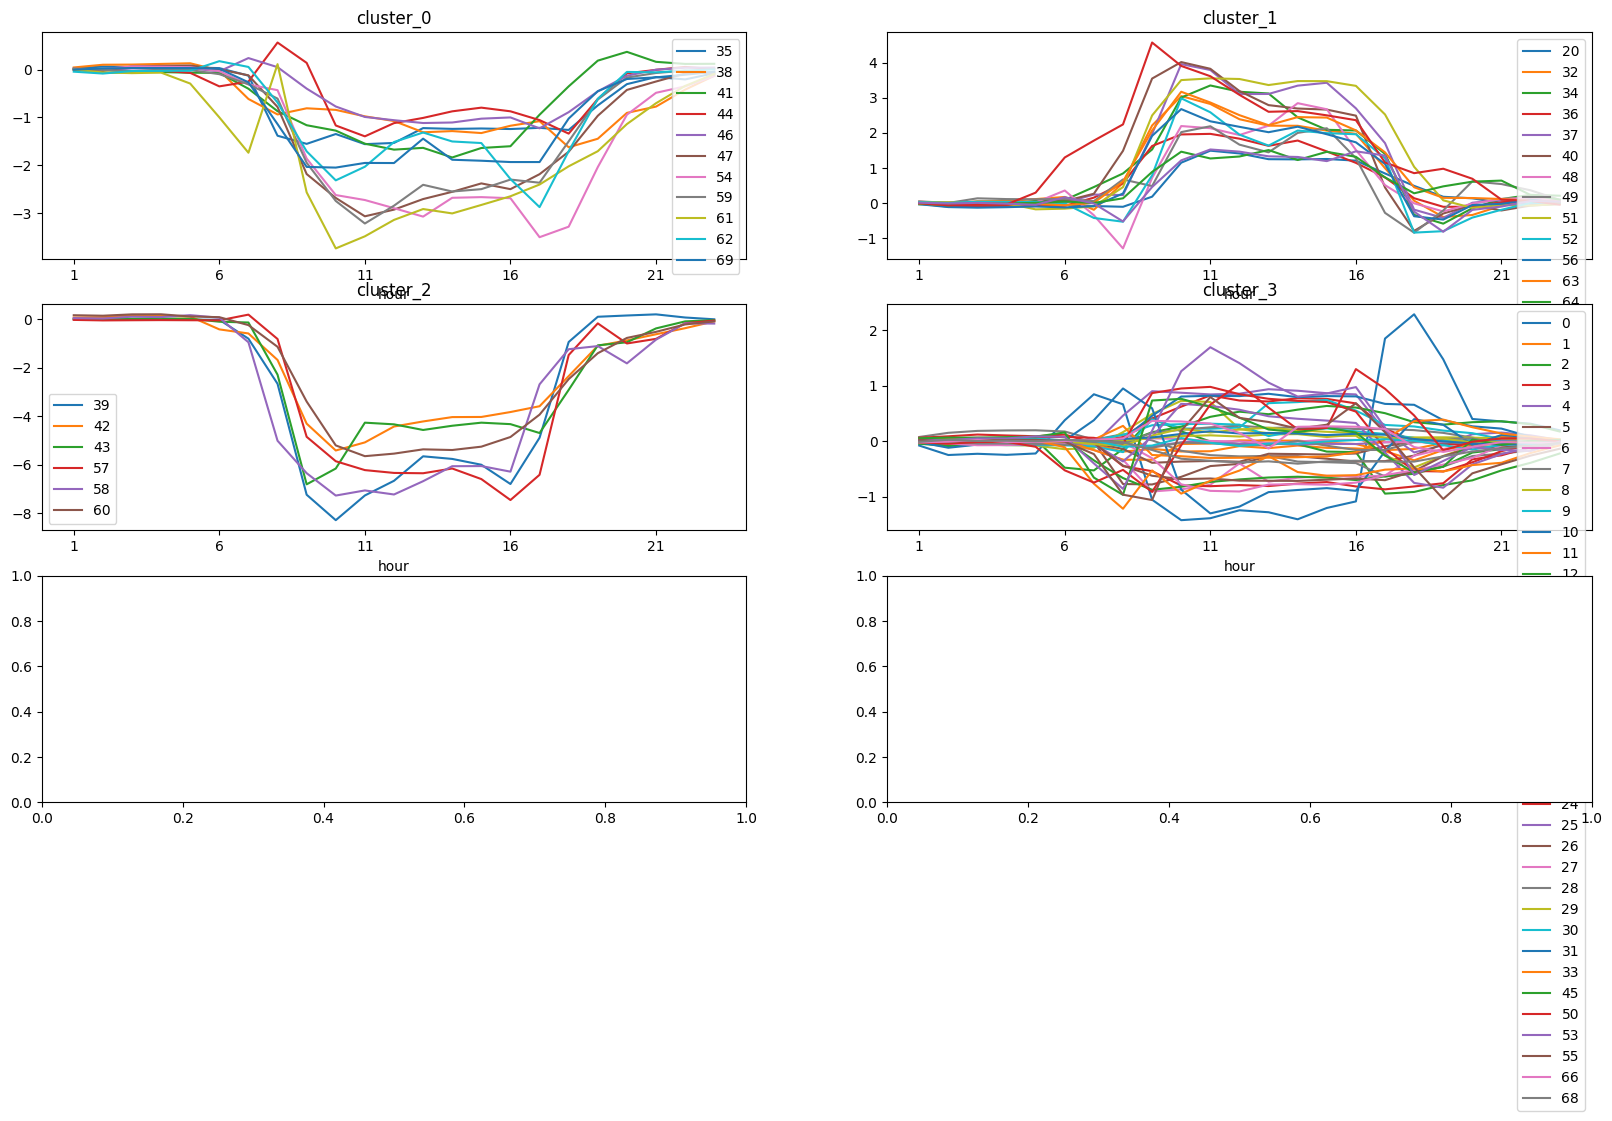

In [42]:
# # 2014-09-01までのデータの時間別変動でstation_idをクラスタリングする
df_status_20140901 = df_prep_status[df_prep_status["datetime"] < "2014-09-01"]
df_status_20140901 = df_status_20140901.groupby(["station_id", "hour"])["bikes_available"].mean().unstack().fillna(0)
# 0時からの変動を計算
df_status_20140901 = df_status_20140901.reset_index()
for i in range(1, 24):
    df_status_20140901[i] = df_status_20140901[i] - df_status_20140901[0]
df_status_20140901 = df_status_20140901.drop(columns=[0])
fig, axes = plt.subplots(3, 2, figsize=(20, 10))
for i in range(n_clusters):
    df_status_20140901[df_station_cluster["cluster"]==i].drop(columns=["station_id"]).T.plot(ax=axes[i//2, i%2], title=f"cluster_{i}")
plt.show()

In [43]:
# datetimeに関する特徴量を作成
df_datetime_atr = df_prep_status[["datetime"]].drop_duplicates().copy()
# datetime
df_datetime_atr["datetime_feat"] = df_datetime_atr["datetime"].apply(lambda x: int(x.strftime('%Y%m%d')))
# 年
df_datetime_atr["year"] = df_datetime_atr["datetime"].dt.year
# 月
df_datetime_atr["month"] = df_datetime_atr["datetime"].dt.month
# 日
df_datetime_atr["day"] = df_datetime_atr["datetime"].dt.day
# 時間
df_datetime_atr["hour"] = df_datetime_atr["datetime"].dt.hour
# 曜日
df_datetime_atr["weekday"] = df_datetime_atr["datetime"].dt.weekday
# 休日か否かのフラグ
df_datetime_atr["holiday"] = df_datetime_atr["weekday"].apply(lambda x: 1 if x in [5, 6] else 0)
list_holiday = [
    "2013-09-02", "2013-10-14", "2013-11-11", "2013-11-28", "2013-12-25",
    "2014-01-01", "2014-01-20", "2014-02-17", "2014-03-31", "2014-05-26", "2014-07-04", "2014-09-01", "2014-11-11", "2014-11-27", "2014-12-25",
    "2015-01-01", "2015-01-19", "2015-02-16", "2015-03-31", "2015-05-25", "2015-07-03", "2015-09-07", "2015-11-11", "2015-11-26", "2015-12-25",
]
list_holiday = [datetime.strptime(x, '%Y-%m-%d').date() for x in list_holiday]
df_datetime_atr["holiday"] = df_datetime_atr.apply(lambda x: 1 if x["datetime"].date() in list_holiday else x["holiday"], axis=1)
df_datetime_atr["weekday"] = df_datetime_atr.apply(lambda x: 6 if x["datetime"].date() in list_holiday else x["weekday"], axis=1)

assert_and_save_feature(df_datetime_atr, ["datetime"], "df_datetime_atr")

missing value: 
datetime         0
datetime_feat    0
year             0
month            0
day              0
hour             0
weekday          0
holiday          0
dtype: int64


In [44]:
# weatherに関する特徴量を作成
df_weather_feat = df_key[["datetime"]].drop_duplicates().copy()
# datetimeに拡張
df_weather_feat["date"] = df_weather_feat["datetime"].dt.date
df_weather_feat = pd.merge(df_weather_feat, df_prep_weather, on=["date"], how="left")
df_weather_feat = df_weather_feat.drop(columns=["date"])
# ダミー変数化
df_weather_feat = pd.get_dummies(df_weather_feat, columns=['events'], drop_first=True, dtype="int64")

assert_and_save_feature(df_weather_feat, ["datetime"], "df_weather_feat")

missing value: 
datetime                   0
max_temperature            0
mean_temperature           0
min_temperature            0
max_dew_point              0
mean_dew_point             0
min_dew_point              0
max_humidity               0
mean_humidity              0
min_humidity               0
max_sea_level_pressure     0
mean_sea_level_pressure    0
min_sea_level_pressure     0
max_visibility             0
mean_visibility            0
min_visibility             0
max_wind_Speed             0
mean_wind_speed            0
precipitation              0
cloud_cover                0
wind_dir_degrees           0
events_Fog-Rain            0
events_Rain                0
dtype: int64


In [45]:
# 移動特徴量の作成
def create_rolling_feature(df, key_cols, target_col, window_sizes, group_col="station_id"):
    df = df.sort_values(key_cols)
    df_rolling = df[key_cols+[target_col]].copy()
    for window in window_sizes:
        # 移動平均
        av_col_name = f"{target_col}_av{window}"
        df_rolling[av_col_name] = df_rolling.groupby(group_col)[target_col].transform(lambda x: x.rolling(window=window, min_periods=1).mean())
        # 移動標準偏差
        std_col_name = f"{target_col}_std{window}"
        df_rolling[std_col_name] = df_rolling.groupby(group_col)[target_col].transform(lambda x: x.rolling(window=window, min_periods=1).std())
        # 移動最大値
        max_col_name = f"{target_col}_max{window}"
        df_rolling[max_col_name] = df_rolling.groupby(group_col)[target_col].transform(lambda x: x.rolling(window=window, min_periods=1).max())
        # 移動最小値
        min_col_name = f"{target_col}_min{window}"
        df_rolling[min_col_name] = df_rolling.groupby(group_col)[target_col].transform(lambda x: x.rolling(window=window, min_periods=1).min())
        # 移動変動係数
        cv_col_name = f"{target_col}_cv{window}"
        df_rolling[cv_col_name] = df_rolling[std_col_name] / df_rolling[av_col_name]
    # df_rolling = df_rolling.drop(columns=[target_col])
    return df_rolling

In [46]:
window_sizes = [3, 7, 24, 48]
df_bikes_available_rolling = create_rolling_feature(df_bikes_available_fillna, ["station_id", "datetime"], "bikes_available", window_sizes)
assert_and_save_feature(df_bikes_available_rolling, ["station_id", "datetime"], "df_bikes_available_rolling")
df_demand_rolling = create_rolling_feature(df_demand, ["station_id", "datetime"], "demand", window_sizes)
assert_and_save_feature(df_demand_rolling, ["station_id", "datetime"], "df_demand_rolling")
df_supply_rolling = create_rolling_feature(df_supply, ["station_id", "datetime"], "supply", window_sizes)
assert_and_save_feature(df_supply_rolling, ["station_id", "datetime"], "df_supply_rolling")
df_intervention_rolling = create_rolling_feature(df_intervention_fillna, ["station_id", "datetime"], "intervention", window_sizes)
assert_and_save_feature(df_intervention_rolling, ["station_id", "datetime"], "df_intervention_rolling")

missing value: 
station_id                    0
datetime                      0
bikes_available          214805
bikes_available_av3      198005
bikes_available_std3     214875
bikes_available_max3     198005
bikes_available_min3     198005
bikes_available_cv3      216476
bikes_available_av7      164405
bikes_available_std7     181275
bikes_available_max7     164405
bikes_available_min7     164405
bikes_available_cv7      182029
bikes_available_av24      21605
bikes_available_std24     38475
bikes_available_max24     21605
bikes_available_min24     21605
bikes_available_cv24      38813
bikes_available_av48      21605
bikes_available_std48     21675
bikes_available_max48     21605
bikes_available_min48     21605
bikes_available_cv48      21677
dtype: int64
missing value: 
station_id           0
datetime             0
demand               0
demand_av3           0
demand_std3         70
demand_max3          0
demand_min3          0
demand_cv3      740086
demand_av7           0
demand_std7 

In [47]:
# 欠損値補完
df_bikes_available_rolling_fillna = load_feature("df_bikes_available_rolling")
df_bikes_available_rolling_fillna = df_bikes_available_rolling_fillna.ffill()
assert_and_save_feature(df_bikes_available_rolling_fillna, ["station_id", "datetime"], "df_bikes_available_rolling_fillna")

missing value: 
station_id               0
datetime                 0
bikes_available          0
bikes_available_av3      0
bikes_available_std3     1
bikes_available_max3     0
bikes_available_min3     0
bikes_available_cv3      1
bikes_available_av7      0
bikes_available_std7     1
bikes_available_max7     0
bikes_available_min7     0
bikes_available_cv7      1
bikes_available_av24     0
bikes_available_std24    1
bikes_available_max24    0
bikes_available_min24    0
bikes_available_cv24     1
bikes_available_av48     0
bikes_available_std48    1
bikes_available_max48    0
bikes_available_min48    0
bikes_available_cv48     1
dtype: int64


In [48]:
# 増減率の作成
def create_increase_rate_feature(df, key_cols, target_col, window_sizes, group_col="station_id"):
    df = df.sort_values(key_cols)
    df_rate = df[key_cols+[target_col]].copy()
    for window in window_sizes:
        # 増減率
        rate_col_name = f"{target_col}_ir{window}"
        df_rate[rate_col_name] = df_rate.groupby(group_col)[target_col].pct_change(window, fill_method=None)
    df_rate = df_rate.drop(columns=[target_col])
    return df_rate

In [49]:
window_sizes = [3, 7, 24, 48]
df_bikes_available_lr = create_increase_rate_feature(df_bikes_available_fillna, ["station_id", "datetime"], "bikes_available", window_sizes)
assert_and_save_feature(df_bikes_available_lr, ["station_id", "datetime"], "df_bikes_available_lr")
df_demand_lr = create_increase_rate_feature(df_demand, ["station_id", "datetime"], "demand", window_sizes)
assert_and_save_feature(df_demand_lr, ["station_id", "datetime"], "df_demand_lr")
df_supply_lr = create_increase_rate_feature(df_supply, ["station_id", "datetime"], "supply", window_sizes)
assert_and_save_feature(df_supply_lr, ["station_id", "datetime"], "df_supply_lr")
df_intervention_lr = create_increase_rate_feature(df_intervention_fillna, ["station_id", "datetime"], "intervention", window_sizes)
assert_and_save_feature(df_intervention_lr, ["station_id", "datetime"], "df_intervention_lr")

# 欠損値補完
df_bikes_available_lr_fillna = load_feature("df_bikes_available_lr")
df_bikes_available_lr_fillna = df_bikes_available_lr_fillna.ffill()
assert_and_save_feature(df_bikes_available_lr_fillna, ["station_id", "datetime"], "df_bikes_available_lr_fillna")

missing value: 
station_id                   0
datetime                     0
bikes_available_ir3     241487
bikes_available_ir7     274523
bikes_available_ir24    410099
bikes_available_ir48    315019
dtype: int64
missing value: 
station_id          0
datetime            0
demand_ir3     793639
demand_ir7     753285
demand_ir24    823738
demand_ir48    810087
dtype: int64
missing value: 
station_id          0
datetime            0
supply_ir3     801029
supply_ir7     762456
supply_ir24    830503
supply_ir48    816947
dtype: int64
missing value: 
station_id                 0
datetime                   0
intervention_ir3      978193
intervention_ir7      979131
intervention_ir24    1029235
intervention_ir48    1000421
dtype: int64
missing value: 
station_id               0
datetime                 0
bikes_available_ir3      3
bikes_available_ir7      7
bikes_available_ir24    24
bikes_available_ir48    48
dtype: int64


In [50]:
# 欠損値補完
df_bikes_available_rolling_fillna = load_feature("df_bikes_available_rolling")
for col in df_bikes_available_rolling_fillna.columns:
    df_bikes_available_rolling_fillna = create_fillna_feature(df_bikes_available_rolling_fillna, "df_bikes_available_rolling")
assert_and_save_feature(df_bikes_available_fillna, ["station_id", "datetime"], "df_bikes_available_rolling_fillna")

missing value: 
station_id              0
datetime                0
bikes_available    214805
dtype: int64


In [51]:
# dock_count_rateの作成
df_bikes_available_rate = load_feature("df_bikes_available_fillna").copy()
df_bikes_available_rate = pd.merge(df_bikes_available_rate, df_station_atr[["station_id", "dock_count"]], on="station_id", how="left")
df_bikes_available_rate["dock_count_rate"] = df_bikes_available_rate["bikes_available"] / df_bikes_available_rate["dock_count"]
df_bikes_available_rate = df_bikes_available_rate.drop(columns=["bikes_available", "dock_count"])
assert_and_save_feature(df_bikes_available_rate, ["station_id", "datetime"], "df_bikes_available_rate")

missing value: 
station_id              0
datetime                0
dock_count_rate    214805
dtype: int64


In [52]:
# dock_count_rateのラグ特徴量を作成
df_bikes_available_rate_lag = create_lag_feature(df_bikes_available_rate, ["station_id", "datetime"], ["dock_count_rate"], 24)
assert_and_save_feature(df_bikes_available_rate_lag, ["station_id", "datetime"], "df_bikes_available_rate_lag")

missing value: 
station_id                    0
datetime                      0
dock_count_rate_lag0     214805
dock_count_rate_lag1     214875
dock_count_rate_lag2     214945
dock_count_rate_lag3     215015
dock_count_rate_lag4     215085
dock_count_rate_lag5     215155
dock_count_rate_lag6     215225
dock_count_rate_lag7     215295
dock_count_rate_lag8     215365
dock_count_rate_lag9     215435
dock_count_rate_lag10    215505
dock_count_rate_lag11    215575
dock_count_rate_lag12    215645
dock_count_rate_lag13    215715
dock_count_rate_lag14    215785
dock_count_rate_lag15    215855
dock_count_rate_lag16    215925
dock_count_rate_lag17    215995
dock_count_rate_lag18    216065
dock_count_rate_lag19    216135
dock_count_rate_lag20    216205
dock_count_rate_lag21    216275
dock_count_rate_lag22    216345
dock_count_rate_lag23    216415
dock_count_rate_lag24    216485
dtype: int64


In [53]:
# df_bikes_available_trip_fillna
# tripデータでbikes_availableを補完する
df_key = load_feature("df_key")
df_bikes_available_fillna = load_feature("df_bikes_available_fillna")
df_demand_cumsum = load_feature("df_demand_cumsum")
df_supply_cumsum = load_feature("df_supply_cumsum")

df_bikes_trip = df_key.copy()
df_bikes_trip = pd.merge(df_bikes_trip, df_demand_cumsum, on=["station_id", "datetime"], how="left")
df_bikes_trip = pd.merge(df_bikes_trip, df_supply_cumsum, on=["station_id", "datetime"], how="left")

df_bikes_00 = df_bikes_available_fillna[df_bikes_available_fillna["datetime"].dt.hour==0][["station_id", "datetime", "bikes_available"]].copy()
df_bikes_00["date"] = df_bikes_00["datetime"].dt.date
df_bikes_00 = df_bikes_00.rename(columns={"bikes_available": "bikes_available_00"})
df_bikes_00 = df_bikes_00[["station_id", "date", "bikes_available_00"]]

df_bikes_trip["date"] = df_bikes_trip["datetime"].dt.date
df_bikes_trip = pd.merge(df_bikes_trip, df_bikes_00, on=["station_id", "date"], how="left")
df_bikes_trip = df_bikes_trip.drop(columns=["date"])

# 補完したデータにはフラグを立てる
df_bikes_trip["bikes_available"] = df_bikes_trip["bikes_available_00"] + df_bikes_trip["demand_cumsum"] + df_bikes_trip["supply_cumsum"]
df_bikes_trip = df_bikes_trip[["station_id", "datetime", "bikes_available"]]
df_bikes_available_trip_fillna = pd.merge(df_bikes_available_fillna, df_bikes_trip, on=["station_id", "datetime"], how="left", suffixes=("", "_pred"))
df_bikes_available_trip_fillna_00 = df_bikes_available_trip_fillna.copy()
df_bikes_available_trip_fillna_00["is_trip_fillna"] = df_bikes_available_trip_fillna_00.apply(lambda x: 1 if pd.isna(x["bikes_available"]) else 0, axis=1).shift(-1)
df_bikes_available_trip_fillna_00 = df_bikes_available_trip_fillna_00[df_bikes_available_trip_fillna_00["datetime"].dt.hour==0]
df_bikes_available_trip_fillna = pd.merge(df_bikes_available_trip_fillna, df_bikes_available_trip_fillna_00[["station_id", "datetime", "is_trip_fillna"]], on=["station_id", "datetime"], how="left")
df_bikes_available_trip_fillna["is_trip_fillna"] = df_bikes_available_trip_fillna["is_trip_fillna"].fillna(0)
df_bikes_available_trip_fillna["bikes_available"] = df_bikes_available_trip_fillna.apply(lambda x: x["bikes_available_pred"] if pd.isna(x["bikes_available"]) else x["bikes_available"], axis=1)
df_bikes_available_trip_fillna = df_bikes_available_trip_fillna.drop(columns=["bikes_available_pred"])

# 負の値を0に変換
df_bikes_available_trip_fillna["bikes_available"] = df_bikes_available_trip_fillna["bikes_available"].apply(lambda x: 0 if x < 0 else x)

assert_and_save_feature(df_bikes_available_trip_fillna[["station_id","datetime","bikes_available"]], ["station_id", "datetime"], "df_bikes_available_trip_fillna")
assert_and_save_feature(df_bikes_available_trip_fillna[["station_id","datetime","is_trip_fillna"]], ["station_id", "datetime"], "df_is_trip_fillna")

missing value: 
station_id             0
datetime               0
bikes_available    21605
dtype: int64
missing value: 
station_id        0
datetime          0
is_trip_fillna    0
dtype: int64


In [54]:
# ラグ特徴量の作成
lag = 48
df_bikes_available_lag = load_feature("df_bikes_available_trip_fillna")
df_bikes_available_lag = create_lag_feature(df_bikes_available_lag, ["station_id", "datetime"], ["bikes_available"], lag)
assert_and_save_feature(df_bikes_available_lag, ["station_id", "datetime"], "df_bikes_available_trip_fillna_lag")

missing value: 
station_id                   0
datetime                     0
bikes_available_lag0     21605
bikes_available_lag1     21675
bikes_available_lag2     21745
bikes_available_lag3     21815
bikes_available_lag4     21885
bikes_available_lag5     21955
bikes_available_lag6     22025
bikes_available_lag7     22095
bikes_available_lag8     22165
bikes_available_lag9     22235
bikes_available_lag10    22305
bikes_available_lag11    22375
bikes_available_lag12    22445
bikes_available_lag13    22515
bikes_available_lag14    22585
bikes_available_lag15    22655
bikes_available_lag16    22725
bikes_available_lag17    22795
bikes_available_lag18    22865
bikes_available_lag19    22935
bikes_available_lag20    23005
bikes_available_lag21    23075
bikes_available_lag22    23145
bikes_available_lag23    23215
bikes_available_lag24    23285
bikes_available_lag25    23355
bikes_available_lag26    23425
bikes_available_lag27    23495
bikes_available_lag28    23565
bikes_available_lag29  

In [55]:
def create_lag_feature_shift(df, key_cols, target_cols, lag, use_latest=False):
    """1期前のデータからのlag特徴量を作成
    """
    # shiftを利用してlag特徴量を作成
    df = df.sort_values(key_cols)
    df_lag = df[key_cols].copy()
    start_lag = 0 if use_latest else 1
    for target_col in target_cols:
        for i in range(start_lag, lag+1): # 当日のデータは含めない
            df_shift = df[key_cols + [target_col]].copy()
            df_shift[f"{target_col}_lag{i}"] = df_shift.groupby("station_id")[target_col].shift(i)
            df_shift[f"{target_col}_lag{i}"] = np.log1p(df_shift[f"{target_col}_lag{i}"]) # 対数変換
            df_shift = df_shift.drop(columns=[target_col])
            df_lag = pd.merge(df_lag, df_shift, on=key_cols, how="left")
    return df_lag

def calculate_slope_with_pvalue(y):
        x = np.arange(len(y))  # 0, 1, 2, 3のインデックス
        slope, _, _, p_value, _ = linregress(x, y)
        # p値が0.1以下の場合、傾きを0に設定
        return 0 if p_value < 0.1 else slope

# 移動特徴量の作成
# def create_rolling_feature_shift(df, key_cols, target_col, window_sizes, group_col="station_id"):
#     """1期前のデータからの期間の移動特徴量を作成
#     """
#     df = df.sort_values(key_cols)
#     df_rolling = df[key_cols+[target_col]].copy()
#     for window in window_sizes:
#         # 移動平均
#         av_col_name = f"{target_col}_av{window}"
#         df_rolling[av_col_name] = df_rolling.groupby(group_col)[target_col].transform(lambda x: x.rolling(window=window, min_periods=1).mean())
#         df_rolling[av_col_name] = df_rolling.groupby(group_col)[av_col_name].shift(1)
#         # 移動標準偏差
#         std_col_name = f"{target_col}_std{window}"
#         df_rolling[std_col_name] = df_rolling.groupby(group_col)[target_col].transform(lambda x: x.rolling(window=window, min_periods=1).std())
#         df_rolling[std_col_name] = df_rolling.groupby(group_col)[std_col_name].shift(1)
#         # 移動最大値
#         max_col_name = f"{target_col}_max{window}"
#         df_rolling[max_col_name] = df_rolling.groupby(group_col)[target_col].transform(lambda x: x.rolling(window=window, min_periods=1).max())
#         df_rolling[max_col_name] = df_rolling.groupby(group_col)[max_col_name].shift(1)
#         # 移動最小値
#         min_col_name = f"{target_col}_min{window}"
#         df_rolling[min_col_name] = df_rolling.groupby(group_col)[target_col].transform(lambda x: x.rolling(window=window, min_periods=1).min())
#         df_rolling[min_col_name] = df_rolling.groupby(group_col)[min_col_name].shift(1)
#         # 移動変動係数
#         cv_col_name = f"{target_col}_cv{window}"
#         df_rolling[cv_col_name] = df_rolling[std_col_name] / df_rolling[av_col_name]
#         df_rolling[cv_col_name] = df_rolling.groupby(group_col)[cv_col_name].shift(1)
#         # 増減率
#         rate_col_name = f"{target_col}_ir{window}"
#         df_rolling[rate_col_name] = df_rolling.groupby(group_col)[target_col].pct_change(window, fill_method=None)
#         df_rolling[rate_col_name] = df_rolling.groupby(group_col)[rate_col_name].shift(1)
#     df_rolling = df_rolling.drop(columns=[target_col])
#     return df_rolling

In [56]:
def crete_timefeat_hour0(df, target_col):
    # 0時時点までのデータで作成した特徴量
    # 各日の０時時点に対して特徴量が作られる,最新断面まで利用可能
    df_timefeat_hour0 = load_feature("df_key").query("datetime.dt.hour==0").copy()
    # ラグ特徴量
    lag = 24
    df_bikes_hour0_lag = create_lag_feature_shift(df, ["station_id", "datetime"], [target_col], lag, use_latest=True)
    # 移動特徴量
    df_bikes_hour0_rolling = df_bikes_hour0_lag[["station_id", "datetime"]].copy()
    window_sizes = [3, 7, 24, 48, 72]
    df_bikes_hour0_lag_ = create_lag_feature_shift(df, ["station_id", "datetime"], [target_col], max(window_sizes), use_latest=True)
    for window in window_sizes:
        # 移動平均
        av_col_name = f"{target_col}_av{window}"
        df_bikes_hour0_rolling[av_col_name] = df_bikes_hour0_lag_[[f"{target_col}_lag{i}" for i in range(0, window)]].mean(axis=1)
        # 移動標準偏差
        std_col_name = f"{target_col}_std{window}"
        df_bikes_hour0_rolling[std_col_name] = df_bikes_hour0_lag_[[f"{target_col}_lag{i}" for i in range(0, window)]].std(axis=1)
        # 移動最大値
        max_col_name = f"{target_col}_max{window}"
        df_bikes_hour0_rolling[max_col_name] = df_bikes_hour0_lag_[[f"{target_col}_lag{i}" for i in range(0, window)]].max(axis=1)
        # 移動最小値
        min_col_name = f"{target_col}_min{window}"
        df_bikes_hour0_rolling[min_col_name] = df_bikes_hour0_lag_[[f"{target_col}_lag{i}" for i in range(0, window)]].min(axis=1)
        # 移動変動係数
        cv_col_name = f"{target_col}_cv{window}"
        df_bikes_hour0_rolling[cv_col_name] = df_bikes_hour0_rolling[std_col_name] / df_bikes_hour0_rolling[av_col_name]
    # ゴールデンクロス特徴量
    short = 3
    long = 24
    gc_col_name = f"{target_col}_gc_{short}_{long}"
    df_bikes_hour0_rolling[gc_col_name] = df_bikes_hour0_rolling[f"{target_col}_av{short}"] - df_bikes_hour0_rolling[f"{target_col}_av{long}"]
    # トレンド特徴量
    df_bikes_hourX_av_trend = df_bikes_hour0_rolling[["station_id", "datetime"]].copy()
    # target_av_col = f"{target_col}_av3"
    # windows = [24]
    # for window in windows:
    #     trend_col_name = f"{target_col}_av_trend{window}"
    #     for station_id in df_bikes_hourX_av_trend['station_id'].unique():
    #         station_df = df_bikes_hour0_rolling[df_bikes_hour0_rolling['station_id'] == station_id]
    #         trend = station_df[target_av_col].rolling(window=window).apply(calculate_slope_with_pvalue, raw=True)
    #         df_bikes_hourX_av_trend.loc[df_bikes_hourX_av_trend['station_id'] == station_id, trend_col_name] = trend

    # マージ
    df_timefeat_hour0 = pd.merge(df_timefeat_hour0, df_bikes_hour0_lag, on=["station_id", "datetime"], how="left")
    df_timefeat_hour0 = pd.merge(df_timefeat_hour0, df_bikes_hour0_rolling, on=["station_id", "datetime"], how="left")
    df_timefeat_hour0 = pd.merge(df_timefeat_hour0, df_bikes_hourX_av_trend, on=["station_id", "datetime"], how="left")

    return df_timefeat_hour0

In [57]:
df = load_feature("df_bikes_available_trip_fillna")
# 0時時点までのデータで特徴量生成
df_timefeat_hour0 = crete_timefeat_hour0(df, "bikes_available")

In [58]:
def create_timefeat_day_hourX(df, target_col, hour):
    # 24時間おきのデータで作成した特徴量
    # 予測対象時間に対して特徴量が作られる
    df_timefeat_day_hourX = load_feature("df_key").query(f"datetime.dt.hour=={hour}").copy()
    df_bikes_hourX = df.query(f"datetime.dt.hour=={hour}").copy()
    df_bikes_hourX = df_bikes_hourX.rename(columns={target_col: f"{target_col}_day"})

    # ラグ特徴量
    df_bikes_hourX_lag_day_30 = create_lag_feature_shift(df_bikes_hourX, ["station_id", "datetime"], [f"{target_col}_day"], 30)
    df_bikes_hourX_lag_day_60 = create_lag_feature_shift(df_bikes_hourX, ["station_id", "datetime"], [f"{target_col}_day"], 60)

    # 移動特徴量
    df_bikes_hourX_lag_day = df_bikes_hourX_lag_day_60.copy()
    df_timefeat_hourX_rolling_day = df_bikes_hourX_lag_day[["station_id", "datetime"]].copy()
    window_sizes = [3, 7, 30, 60]
    for window in window_sizes:
        # 移動平均
        av_col_name = f"{target_col}_day_av{window}"
        df_timefeat_hourX_rolling_day[av_col_name] = df_bikes_hourX_lag_day[[f"{target_col}_day_lag{i}" for i in range(1,window+1)]].mean(axis=1)
        # 移動標準偏差
        std_col_name = f"{target_col}_day_std{window}"
        df_timefeat_hourX_rolling_day[std_col_name] = df_bikes_hourX_lag_day[[f"{target_col}_day_lag{i}" for i in range(1,window+1)]].std(axis=1)
        # 移動最大値
        max_col_name = f"{target_col}_day_max{window}"
        df_timefeat_hourX_rolling_day[max_col_name] = df_bikes_hourX_lag_day[[f"{target_col}_day_lag{i}" for i in range(1,window+1)]].max(axis=1)
        # 移動最小値
        min_col_name = f"{target_col}_day_min{window}"
        df_timefeat_hourX_rolling_day[min_col_name] = df_bikes_hourX_lag_day[[f"{target_col}_day_lag{i}" for i in range(1,window+1)]].min(axis=1)
        # 移動変動係数
        cv_col_name = f"{target_col}_day_cv{window}"
        df_timefeat_hourX_rolling_day[cv_col_name] = df_timefeat_hourX_rolling_day[std_col_name] / df_timefeat_hourX_rolling_day[av_col_name]

    # ゴールデンクロス特徴量
    shorts = [3, 7]
    long = 30
    for short in shorts:
        gc_col_name = f"{target_col}_day_gc_{short}_{long}"
        df_timefeat_hourX_rolling_day[gc_col_name] = df_timefeat_hourX_rolling_day[f"{target_col}_day_av{short}"] - df_timefeat_hourX_rolling_day[f"{target_col}_day_av{long}"]

    # 前日比変化率
    df_timefeat_hourX_ir_day = df_bikes_hourX_lag_day[["station_id", "datetime"]].copy()
    rate_col_name = f"{target_col}_day_ir1"
    df_timefeat_hourX_ir_day[rate_col_name] = (df_bikes_hourX_lag_day[f"{target_col}_day_lag1"] - df_bikes_hourX_lag_day[f"{target_col}_day_lag2"]) / df_bikes_hourX_lag_day[f"{target_col}_day_lag2"]
    ## infをNaNに変換
    df_timefeat_hourX_ir_day[rate_col_name] = df_timefeat_hourX_ir_day[rate_col_name].replace([np.inf, -np.inf], np.nan)

    # トレンド特徴量
    df_timefeat_hourX_av_trend_day = df_timefeat_hourX_rolling_day[["station_id", "datetime"]].copy()
    target_av_col = f"{target_col}_day_av3"
    windows = [3, 7, 30]
    for window in windows:
        trend_col_name = f"{target_col}_day_av_trend{window}"
        for station_id in df_timefeat_hourX_av_trend_day['station_id'].unique():
            station_df = df_timefeat_hourX_rolling_day[df_timefeat_hourX_rolling_day['station_id'] == station_id]
            trend = station_df[target_av_col].rolling(window=window).apply(calculate_slope_with_pvalue, raw=True)
            df_timefeat_hourX_av_trend_day.loc[df_timefeat_hourX_av_trend_day['station_id'] == station_id, trend_col_name] = trend

    # マージ
    df_timefeat_day_hourX = pd.merge(df_timefeat_day_hourX, df_bikes_hourX_lag_day_30, on=["station_id", "datetime"], how="left")
    df_timefeat_day_hourX = pd.merge(df_timefeat_day_hourX, df_timefeat_hourX_rolling_day, on=["station_id", "datetime"], how="left")
    df_timefeat_day_hourX = pd.merge(df_timefeat_day_hourX, df_timefeat_hourX_ir_day, on=["station_id", "datetime"], how="left")
    df_timefeat_day_hourX = pd.merge(df_timefeat_day_hourX, df_timefeat_hourX_av_trend_day, on=["station_id", "datetime"], how="left")

    return df_timefeat_day_hourX

In [59]:
def create_timefeat_week_hourX(df, target_col, hour):

    # 24*7時間おきのデータで作成した特徴量
    df_timefeat_week_hourX = load_feature("df_key").query(f"datetime.dt.hour=={hour}").copy()
    df_bikes_hourX = df.query(f"datetime.dt.hour=={hour}").copy()
    df_bikes_hourX = df_bikes_hourX.rename(columns={target_col: f"{target_col}_week"})

    # ラグ特徴量の作成
    # 7日ごとのラグ特徴量を抽出
    lag = 12
    df_bikes_hourX_lag = create_lag_feature_shift(df_bikes_hourX, ["station_id", "datetime"], [f"{target_col}_week"], 7*lag)
    df_bikes_hourX_lag_week = df_timefeat_week_hourX.copy().sort_values(["station_id", "datetime"])
    for i, lag in enumerate(range(7, 7*lag+1, 7)): # 当日のデータは含めない
        # 対数変換してlagを取る
        df_bikes_hourX_lag_week[f"{target_col}_week_lag{i+1}"] = np.log1p(df_bikes_hourX_lag[f"{target_col}_week_lag{lag}"].values)

    # 移動特徴量
    df_bikes_hourX_rolling_week = df_bikes_hourX_lag_week[["station_id", "datetime"]].copy()
    window_sizes = [3, 7, 11]
    for window in window_sizes:
        # 移動平均
        av_col_name = f"{target_col}_week_av{window}"
        df_bikes_hourX_rolling_week[av_col_name] = df_bikes_hourX_lag_week[[f"{target_col}_week_lag{i}" for i in range(1,window+1)]].mean(axis=1)
        # 移動標準偏差
        std_col_name = f"{target_col}_week_std{window}"
        df_bikes_hourX_rolling_week[std_col_name] = df_bikes_hourX_lag_week[[f"{target_col}_week_lag{i}" for i in range(1,window+1)]].std(axis=1)
        # 移動最大値
        max_col_name = f"{target_col}_week_max{window}"
        df_bikes_hourX_rolling_week[max_col_name] = df_bikes_hourX_lag_week[[f"{target_col}_week_lag{i}" for i in range(1,window+1)]].max(axis=1)
        # 移動最小値
        min_col_name = f"{target_col}_week_min{window}"
        df_bikes_hourX_rolling_week[min_col_name] = df_bikes_hourX_lag_week[[f"{target_col}_week_lag{i}" for i in range(1,window+1)]].min(axis=1)
        # 移動変動係数
        cv_col_name = f"{target_col}_week_cv{window}"
        df_bikes_hourX_rolling_week[cv_col_name] = df_bikes_hourX_rolling_week[std_col_name] / df_bikes_hourX_rolling_week[av_col_name]

    # ゴールデンクロス特徴量
    shorts = [3]
    long = 11
    for short in shorts:
        gc_col_name = f"{target_col}_week_gc_{short}_{long}"
        df_bikes_hourX_rolling_week[gc_col_name] = df_bikes_hourX_rolling_week[f"{target_col}_week_av{short}"] - df_bikes_hourX_rolling_week[f"{target_col}_week_av{long}"]

    # 先週比増加率
    df_bikes_hourX_ir_week = df_bikes_hourX_lag_week[["station_id", "datetime"]].copy()
    rate_col_name = f"{target_col}_week_ir1"
    df_bikes_hourX_ir_week[rate_col_name] = (df_bikes_hourX_lag_week[f"{target_col}_week_lag1"] - df_bikes_hourX_lag_week[f"{target_col}_week_lag2"]) / df_bikes_hourX_lag_week[f"{target_col}_week_lag2"]
    # infをNaNに変換
    df_bikes_hourX_ir_week[rate_col_name] = df_bikes_hourX_ir_week[rate_col_name].replace([np.inf, -np.inf], np.nan)

    # トレンド特徴量
    df_bikes_hourX_av_trend_week = df_bikes_hourX_rolling_week[["station_id", "datetime"]].copy()
    target_av_col = f"{target_col}_week_av3"
    windows = [3, 7]
    for window in windows:
        trend_col_name = f"{target_col}_week_av_trend{window}"
        for station_id in df_bikes_hourX_av_trend_week['station_id'].unique():
            station_df = df_bikes_hourX_rolling_week[df_bikes_hourX_rolling_week['station_id'] == station_id]
            trend = station_df[target_av_col].rolling(window=window).apply(calculate_slope_with_pvalue, raw=True)
            df_bikes_hourX_av_trend_week.loc[df_bikes_hourX_av_trend_week['station_id'] == station_id, trend_col_name] = trend

    # マージ
    df_timefeat_week_hourX = pd.merge(df_timefeat_week_hourX, df_bikes_hourX_lag_week, on=["station_id", "datetime"], how="left")
    df_timefeat_week_hourX = pd.merge(df_timefeat_week_hourX, df_bikes_hourX_rolling_week, on=["station_id", "datetime"], how="left")
    df_timefeat_week_hourX = pd.merge(df_timefeat_week_hourX, df_bikes_hourX_ir_week, on=["station_id", "datetime"], how="left")
    df_timefeat_week_hourX = pd.merge(df_timefeat_week_hourX, df_bikes_hourX_av_trend_week, on=["station_id", "datetime"], how="left")

    return df_timefeat_week_hourX

In [60]:
def create_hour_bikes_dataset(hour):

    df_timefeat_hourX = load_feature("df_key").copy()
    # X時のデータを抽出
    df_timefeat_hourX = df_timefeat_hourX[df_timefeat_hourX['datetime'].dt.hour == hour]

    # 目的変数
    df_timefeat_hourX = pd.merge(df_timefeat_hourX, load_feature("df_bikes_available_trip_fillna"), on=["station_id", "datetime"], how="left")

    # predictフラグを付与
    df_timefeat_hourX = pd.merge(df_timefeat_hourX, load_feature("df_predict_add_valid_flag"), on=["station_id", "datetime"], how="left")

    df = load_feature("df_bikes_available_trip_fillna")
    # 0時時点までのデータで特徴量生成
    df_timefeat_hour0 = load_feature("df_timefeat_hour0")
    # 1日（24時間）おきのデータで特徴量生成
    df_timefeat_day_hourX = create_timefeat_day_hourX(df, "bikes_available", hour)
    # 1週間（24*7時間）おきのデータで特徴量生成
    df_timefeat_week_hourX = create_timefeat_week_hourX(df, "bikes_available", hour)
    # 上記をマージして特徴量とする
    # 0時時点までのデータで作成した特徴量
    df_timefeat_hourX["date"] = df_timefeat_hourX["datetime"].dt.date
    df_timefeat_hour0["date"] = df_timefeat_hour0["datetime"].dt.date
    df_timefeat_hour0 = df_timefeat_hour0.drop(columns=["datetime"])
    df_timefeat_hourX = pd.merge(df_timefeat_hourX, df_timefeat_hour0, on=["station_id", "date"], how="left")
    df_timefeat_hourX = df_timefeat_hourX.drop(columns=["date"])
    # 1日（24時間）おきのデータで作成した特徴量
    df_timefeat_hourX = pd.merge(df_timefeat_hourX, df_timefeat_day_hourX, on=["station_id", "datetime"], how="left")
    # 1週間（24*7時間）おきのデータで作成した特徴量
    df_timefeat_hourX = pd.merge(df_timefeat_hourX, df_timefeat_week_hourX, on=["station_id", "datetime"], how="left")

    # stationに関する特徴量を付与
    df_timefeat_hourX = pd.merge(df_timefeat_hourX, load_feature("df_station_atr"), on="station_id", how="left")

    # datetimeに関する特徴量を付与
    df_timefeat_hourX = pd.merge(df_timefeat_hourX, load_feature("df_datetime_atr"), on="datetime", how="left")

    # 格納
    assert_and_save_feature(df_timefeat_hourX, ["station_id", "datetime"], f"df_timefeat_bikes_available_hour{hour}")

In [61]:
# 0時時点までのデータで特徴量生成
df_timefeat_hour0 = crete_timefeat_hour0(df, "bikes_available")
assert_and_save_feature(df_timefeat_hour0, ["station_id", "datetime"], "df_timefeat_hour0")

missing value: 
station_id                    0
datetime                      0
bikes_available_lag0        904
bikes_available_lag1        968
bikes_available_lag2        968
bikes_available_lag3        968
bikes_available_lag4        968
bikes_available_lag5        968
bikes_available_lag6        968
bikes_available_lag7        968
bikes_available_lag8        968
bikes_available_lag9        968
bikes_available_lag10       968
bikes_available_lag11       968
bikes_available_lag12       968
bikes_available_lag13       970
bikes_available_lag14       970
bikes_available_lag15       971
bikes_available_lag16       971
bikes_available_lag17       972
bikes_available_lag18       972
bikes_available_lag19       973
bikes_available_lag20       974
bikes_available_lag21       974
bikes_available_lag22       974
bikes_available_lag23       974
bikes_available_lag24       974
bikes_available_av3         904
bikes_available_std3        968
bikes_available_max3        904
bikes_available_min3    

In [62]:
for hour in range(1, 24):
    create_hour_bikes_dataset(hour)
    print()

missing value: 
station_id                           0
datetime                             0
bikes_available                    904
predict                              0
bikes_available_lag0               904
bikes_available_lag1               968
bikes_available_lag2               968
bikes_available_lag3               968
bikes_available_lag4               968
bikes_available_lag5               968
bikes_available_lag6               968
bikes_available_lag7               968
bikes_available_lag8               968
bikes_available_lag9               968
bikes_available_lag10              968
bikes_available_lag11              968
bikes_available_lag12              968
bikes_available_lag13              970
bikes_available_lag14              970
bikes_available_lag15              971
bikes_available_lag16              971
bikes_available_lag17              972
bikes_available_lag18              972
bikes_available_lag19              973
bikes_available_lag20              974
bikes_ava

In [63]:
load_feature("df_timefeat_bikes_available_hour1")

,station_id,datetime,bikes_available,predict,bikes_available_lag0,bikes_available_lag1,bikes_available_lag2,bikes_available_lag3,bikes_available_lag4,bikes_available_lag5,bikes_available_lag6,bikes_available_lag7,bikes_available_lag8,bikes_available_lag9,bikes_available_lag10,bikes_available_lag11,bikes_available_lag12,bikes_available_lag13,bikes_available_lag14,bikes_available_lag15,bikes_available_lag16,bikes_available_lag17,bikes_available_lag18,bikes_available_lag19,bikes_available_lag20,bikes_available_lag21,bikes_available_lag22,bikes_available_lag23,bikes_available_lag24,bikes_available_av3,bikes_available_std3,bikes_available_max3,bikes_available_min3,bikes_available_cv3,bikes_available_av7,bikes_available_std7,bikes_available_max7,bikes_available_min7,bikes_available_cv7,bikes_available_av24,bikes_available_std24,bikes_available_max24,bikes_available_min24,bikes_available_cv24,bikes_available_av48,bikes_available_std48,bikes_available_max48,bikes_available_min48,bikes_available_cv48,bikes_available_av72,bikes_available_std72,bikes_available_max72,bikes_available_min72,bikes_available_cv72,bikes_available_gc_3_24,bikes_available_day_lag1,bikes_available_day_lag2,bikes_available_day_lag3,bikes_available_day_lag4,bikes_available_day_lag5,bikes_available_day_lag6,bikes_available_day_lag7,bikes_available_day_lag8,bikes_available_day_lag9,bikes_available_day_lag10,bikes_available_day_lag11,bikes_available_day_lag12,bikes_available_day_lag13,bikes_available_day_lag14,bikes_available_day_lag15,bikes_available_day_lag16,bikes_available_day_lag17,bikes_available_day_lag18,bikes_available_day_lag19,bikes_available_day_lag20,bikes_available_day_lag21,bikes_available_day_lag22,bikes_available_day_lag23,bikes_available_day_lag24,bikes_available_day_lag25,bikes_available_day_lag26,bikes_available_day_lag27,bikes_available_day_lag28,bikes_available_day_lag29,bikes_available_day_lag30,bikes_available_day_av3,bikes_available_day_std3,bikes_available_day_max3,bikes_available_day_min3,bikes_available_day_cv3,bikes_available_day_av7,bikes_available_day_std7,bikes_available_day_max7,bikes_available_day_min7,bikes_available_day_cv7,bikes_available_day_av30,bikes_available_day_std30,bikes_available_day_max30,bikes_available_day_min30,bikes_available_day_cv30,bikes_available_day_av60,bikes_available_day_std60,bikes_available_day_max60,bikes_available_day_min60,bikes_available_day_cv60,bikes_available_day_gc_3_30,bikes_available_day_gc_7_30,bikes_available_day_ir1,bikes_available_day_av_trend3,bikes_available_day_av_trend7,bikes_available_day_av_trend30,bikes_available_week_lag1,bikes_available_week_lag2,bikes_available_week_lag3,bikes_available_week_lag4,bikes_available_week_lag5,bikes_available_week_lag6,bikes_available_week_lag7,bikes_available_week_lag8,bikes_available_week_lag9,bikes_available_week_lag10,bikes_available_week_lag11,bikes_available_week_lag12,bikes_available_week_av3,bikes_available_week_std3,bikes_available_week_max3,bikes_available_week_min3,bikes_available_week_cv3,bikes_available_week_av7,bikes_available_week_std7,bikes_available_week_max7,bikes_available_week_min7,bikes_available_week_cv7,bikes_available_week_av11,bikes_available_week_std11,bikes_available_week_max11,bikes_available_week_min11,bikes_available_week_cv11,bikes_available_week_gc_3_11,bikes_available_week_ir1,bikes_available_week_av_trend3,bikes_available_week_av_trend7,lat,long,dock_count,installation_date,station_id_feat,installation_year,installation_month,installation_day,city_city1,city_city2,city_city3,city_city4,city_city5,cluster,datetime_feat,year,month,day,hour,weekday,holiday
0,0,2013-09-01 01:00:00,11.0,0,2.484907,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.484907,NaN,2.484907,2.484907,NaN,2.484907,NaN,2.484907,2.484907,NaN,2.484907,NaN,2.484907,2.484907,NaN,2.484907,NaN,2.484907,2.484907,NaN,2.484907,NaN,2.484907,2.484907,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [64]:
# ユニバース分割
base_data_name = "df_timefeat_bikes_available"
for hour in range(1, 24):
    data_name = f"{base_data_name}_hour{hour}"
    df = load_feature(data_name)
    df_unv_1 = df[df["city_city2"]==1]
    df_unv_2 = df[df["city_city2"]==0]
    assert_and_save_feature(df_unv_1, ["station_id", "datetime"], f"{base_data_name}_city_2_hour{hour}")
    assert_and_save_feature(df_unv_2, ["station_id", "datetime"], f"{base_data_name}_city_other_hour{hour}")

ストリーミング出力は最後の 5000 行に切り捨てられました。
bikes_available_week_lag4         1738
bikes_available_week_lag5         1983
bikes_available_week_lag6         2228
bikes_available_week_lag7         2473
bikes_available_week_lag8         2718
bikes_available_week_lag9         2963
bikes_available_week_lag10        3208
bikes_available_week_lag11        3453
bikes_available_week_lag12        3698
bikes_available_week_av3          1003
bikes_available_week_std3         1248
bikes_available_week_max3         1003
bikes_available_week_min3         1003
bikes_available_week_cv3          1249
bikes_available_week_av7          1003
bikes_available_week_std7         1248
bikes_available_week_max7         1003
bikes_available_week_min7         1003
bikes_available_week_cv7          1248
bikes_available_week_av11         1003
bikes_available_week_std11        1248
bikes_available_week_max11        1003
bikes_available_week_min11        1003
bikes_available_week_cv11         1248
bikes_available_week_gc_3_11    

In [65]:
print(load_feature("df_timefeat_bikes_available_city_2_hour10").shape)
print(load_feature("df_timefeat_bikes_available_city_other_hour10").shape)

(25550, 163)
(25550, 163)


In [66]:
load_feature("df_timefeat_bikes_available_city_2_hour10")["station_id"].unique()

array([32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48,
       49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65,
       67])

In [67]:
load_feature("df_timefeat_bikes_available_city_other_hour10")["station_id"].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 66, 68,
       69])

In [ ]:
df_ = df_target[(df_target["station_id"]==2) & (df_target["datetime"].dt.hour==10)]
plt.plot(df_["datetime"], df_["bikes_available"])

In [ ]:
df_ = df_target[(df_target["station_id"]==2) & (df_target["datetime"].dt.hour==23)]
plt.plot(df_["datetime"], df_["bikes_available"])

In [ ]:
def get_cv_folds(freq='MS'):
    """CVのfoldを返却
    """
    return pd.date_range("2014-09-01", periods=12, freq=freq)

In [ ]:
get_cv_folds("3MS")

In [ ]:
df_predict_add_valid_flag = load_feature("df_predict_add_valid_flag")
for date in pd.date_range(start="2014-09-01", end="2015-08-01", freq="3MS"):
    print(date)
    print(date + pd.DateOffset(months=3))

In [ ]:
from sklearn.metrics import mean_absolute_error
def metric(va_true, va_pred):
    """評価指標の計算
    """
    score = mean_absolute_error(va_true, va_pred)
    # score = math.sqrt(mean_squared_error(va_true, va_pred))

    return score

In [ ]:
run_name = "lgbm_multimodel_bikes_202410251946"
df_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, f"{run_name}/va_pred.pkl"))
df_true = load_feature("df_target")
df_true_pred = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="inner", suffixes=("", "_pred"))
df_true_pred["weekdays"] = df_true_pred["datetime"].dt.weekday

In [ ]:
df_true_pred_holiday = df_true_pred[df_true_pred["weekdays"].isin([5, 6])]
df_true_pred_weekday = df_true_pred[~df_true_pred["weekdays"].isin([5, 6])]
print("holiday", df_true_pred_holiday.shape)
print(metric(df_true_pred_holiday["bikes_available"], df_true_pred_holiday["bikes_available_pred"]))
print("weekday", df_true_pred_weekday.shape)
print(metric(df_true_pred_weekday["bikes_available"], df_true_pred_weekday["bikes_available_pred"]))

In [ ]:
df_true_pred_staion = pd.merge(df_true_pred, load_feature("df_station_atr"), on="station_id", how="left")
df_true_pred_city1 = df_true_pred_staion[df_true_pred_staion["city_city1"]==1]
df_true_pred_city2 = df_true_pred_staion[df_true_pred_staion["city_city2"]==1]
df_true_pred_city3 = df_true_pred_staion[df_true_pred_staion["city_city3"]==1]
df_true_pred_city4 = df_true_pred_staion[df_true_pred_staion["city_city4"]==1]
df_true_pred_city5 = df_true_pred_staion[df_true_pred_staion["city_city5"]==1]

print("city1", df_true_pred_city1.shape)
print(metric(df_true_pred_city1["bikes_available"], df_true_pred_city1["bikes_available_pred"]))
print("city2", df_true_pred_city2.shape)
print(metric(df_true_pred_city2["bikes_available"], df_true_pred_city2["bikes_available_pred"]))
print("city3", df_true_pred_city3.shape)
print(metric(df_true_pred_city3["bikes_available"], df_true_pred_city3["bikes_available_pred"]))
print("city4", df_true_pred_city4.shape)
print(metric(df_true_pred_city4["bikes_available"], df_true_pred_city4["bikes_available_pred"]))
print("city5", df_true_pred_city5.shape)
print(metric(df_true_pred_city5["bikes_available"], df_true_pred_city5["bikes_available_pred"]))

In [ ]:
df_true_pred_staion = pd.merge(df_true_pred, load_feature("df_station_atr"), on="station_id", how="left")
df_true_pred_city2 = df_true_pred_staion[df_true_pred_staion["city_city2"]==1]
df_true_pred_cityother = df_true_pred_staion[df_true_pred_staion["city_city2"]==0]

print("city2", df_true_pred_city2.shape)
print(metric(df_true_pred_city2["bikes_available"], df_true_pred_city2["bikes_available_pred"]))
print("other", df_true_pred_cityother.shape)
print(metric(df_true_pred_cityother["bikes_available"], df_true_pred_cityother["bikes_available_pred"]))